# Week 02: Analytical Methods & Neural Networks - Homework Solutions
## MECE6313E: Advanced Heat Transfer

**Solutions Set**

This notebook contains the solutions to the homework problems on analytical methods and neural networks. It provides detailed derivations, code implementations, and discussions.

---

## Problem 1: Separation of Variables (SOV)

### Analytical Derivation

**1. Governing Equation:**
$$ \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2} $$

**2. Separation Ansatz:**
Assume $T(x,t) = X(x)\tau(t)$. Substituting into the PDE:
$$ X(x)\tau'(t) = \alpha X''(x)\tau(t) \implies \frac{\tau'(t)}{\alpha \tau(t)} = \frac{X''(x)}{X(x)} = -\lambda^2 $$

**3. Spatial Problem (Sturm-Liouville):**
$$ X''(x) + \lambda^2 X(x) = 0 $$
General solution: $X(x) = A \cos(\lambda x) + B \sin(\lambda x)$.

Boundary Conditions:
- $T(0,t) = 0 \implies X(0) = 0 \implies A \cdot 1 + B \cdot 0 = 0 \implies A=0$.
- $T(L,t) = 0 \implies X(L) = 0 \implies B \sin(\lambda L) = 0$.
For non-trivial solutions ($B \neq 0$), we require $\lambda_n L = n\pi$ for $n=1, 2, \dots$.
Thus, eigenvalues are $\lambda_n = \frac{n\pi}{L}$ and eigenfunctions are $X_n(x) = \sin\left(\frac{n\pi x}{L}\right)$.

**4. Temporal Problem:**
$$ \tau'(t) + \alpha \lambda_n^2 \tau(t) = 0 $$
Solution: $\tau_n(t) = C_n e^{-\alpha \lambda_n^2 t}$.

**5. General Series Solution:**
$$ T(x,t) = \sum_{n=1}^{\infty} c_n \sin\left(\frac{n\pi x}{L}\right) e^{-\alpha \left(\frac{n\pi}{L}\right)^2 t} $$

**6. Initial Condition:**
$$ T(x,0) = 100 \sin\left(\frac{\pi x}{L}\right) = \sum_{n=1}^{\infty} c_n \sin\left(\frac{n\pi x}{L}\right) $$
By orthogonality (or inspection), only the $n=1$ term is non-zero.
$$ c_1 = 100, \quad c_n = 0 \text{ for } n > 1 $$

**Final Solution:**
$$ T(x,t) = 100 \sin\left(\frac{\pi x}{L}\right) e^{-\alpha \left(\frac{\pi}{L}\right)^2 t} $$

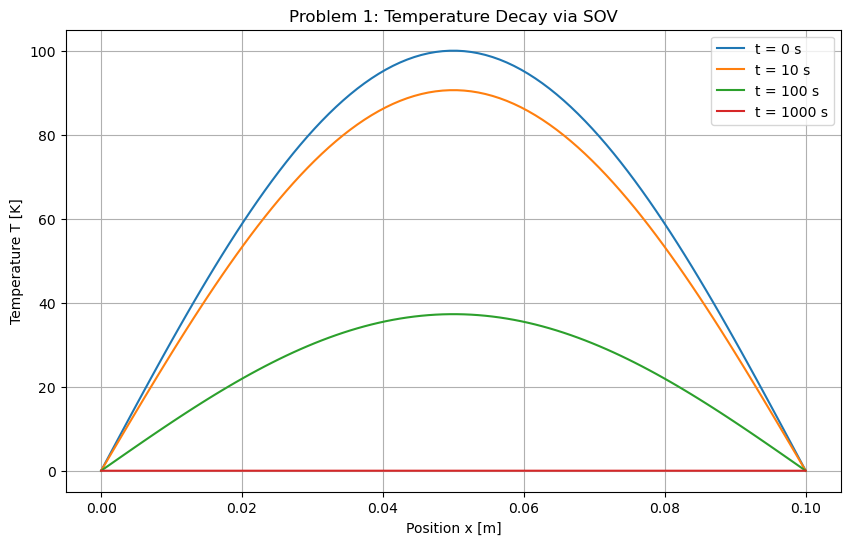

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
L = 0.1  # m
alpha = 1e-5  # m^2/s
times = [0, 10, 100, 1000]  # seconds

def sov_exact_solution(x, t, L=L, alpha=alpha):
    """Exact analytical solution for the specific IC provided."""
    lambda_1 = np.pi / L
    decay = np.exp(-alpha * lambda_1**2 * t)
    return 100 * np.sin(np.pi * x / L) * decay

# General SOV for arbitrary IC (illustrative, not strictly needed for this simple IC)
def sov_general_solution(x, t, N=50):
    """General SOV expansion (checking convergence)."""
    T = np.zeros_like(x)
    for n in range(1, N+1):
        lambda_n = n * np.pi / L
        # For T(x,0) = 100*sin(pi*x/L), only c1 is non-zero
        if n == 1:
            cn = 100
        else:
            cn = 0
        T += cn * np.sin(lambda_n * x) * np.exp(-alpha * lambda_n**2 * t)
    return T

# Plotting
x = np.linspace(0, L, 100)
plt.figure(figsize=(10, 6))

for t in times:
    T_vals = sov_exact_solution(x, t)
    plt.plot(x, T_vals, label=f't = {t} s')

plt.xlabel('Position x [m]')
plt.ylabel('Temperature T [K]')
plt.title('Problem 1: Temperature Decay via SOV')
plt.legend()
plt.grid(True)
plt.show()

### Discussion (Problem 1)

- **Decay:** The solution decays exponentially with time due to the $e^{-\alpha \lambda^2 t}$ term. The decay rate depends on the thermal diffusivity $\alpha$ and the eigenvalue $\lambda_n$.
- **Dominant Mode:** Since the initial condition perfectly matched the first eigenmode ($n=1$), only the fundamental mode exists. In a general case, higher-order modes ($n > 1$) decay much faster because $\lambda_n^2 \propto n^2$. Thus, at late times, the solution is always dominated by the fundamental ($n=1$) mode.
- **Linearity:** The heat equation is a linear PDE, and the boundary conditions are homogeneous. This allows us to superimpose solutions (sum of eigenfunctions), which is the core principle of SOV.
- **Inhomogeneous BCs:** If $T(0,t) = T_0 \neq 0$, the BCs would not be homogeneous, and we could not directly apply SOV. We would transform the variable $u(x,t) = T(x,t) - T_{steady}(x)$ to obtain a problem with homogeneous BCs for $u(x,t)$.

---